In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import os
import scanpy as sc
from scipy.stats import linregress

import matplotlib as mpl

from watermark import watermark
print(watermark())
print(watermark(packages="pandas,numpy,matplotlib,scipy,seaborn"))

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

plt.rcParams['svg.fonttype'] = 'none'

Last updated: 2026-08-19T16:33:00.859678-07:00

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.6.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 63 Stepping 2, GenuineIntel
CPU cores   : 72
Architecture: 64bit

pandas    : 2.2.3
numpy     : 2.1.2
matplotlib: 3.10.7
scipy     : 1.14.1
seaborn   : 0.13.2



### Mean decoded barcodes per mouse cortex cell reported in the text:

In [2]:
means_by_method = pd.read_csv('mean_cnts_by_method.csv')

In [3]:
means_by_method

,gene,seqFISH,Vizgen MERFISH,CosMx,Xenium
0,4930452B06Rik,NaN,0.635114,NaN,NaN
1,6330403K07Rik,NaN,NaN,1.701662,NaN
2,A1cf,NaN,NaN,NaN,0.001124
3,A2m,NaN,0.575704,NaN,0.060121
4,A830009L08Rik,NaN,0.167741,NaN,NaN
...,...,...,...,...,...
5789,Zup1,NaN,NaN,NaN,0.047631
5790,Zwint,NaN,NaN,6.674890,NaN
5791,Zyx,4.552558,NaN,NaN,0.146803
5792,Zzef1,NaN,NaN,NaN,0.332310


In [4]:
# average transcripts per cell for each method:
means_by_method.fillna(0).sum()

gene              4930452B06Rik6330403K07RikA1cfA2mA830009L08Rik...
seqFISH                                                 2804.026746
Vizgen MERFISH                                          1307.630255
CosMx                                                   1741.031157
Xenium                                                  1369.662388
dtype: object

In [5]:
# genes probed by each method
np.logical_not(means_by_method.isna()).sum()

gene              5794
seqFISH            271
Vizgen MERFISH     815
CosMx              950
Xenium            5006
dtype: int64

In [6]:
means_by_method.set_index("gene", inplace=True)

In [7]:
means_by_method.columns

Index(['seqFISH', 'Vizgen MERFISH', 'CosMx', 'Xenium'], dtype='object')

In [8]:
def bootstrap(matched_genes):
    rep_slopes = []
    rep_r_sq_s = []

    rep_intercepts = []
    
    reps = 10000
    n_matched_genes = len(matched_genes)
    for rep in range(reps):
        matched_genes_subsample = matched_genes.sample(n=int(np.ceil(n_matched_genes*0.7)))
        fit = linregress(matched_genes_subsample[method_i], matched_genes_subsample[method_j])

        rep_slopes.append(fit.slope)
        rep_r_sq_s.append(fit.rvalue)
        rep_intercepts.append(fit.intercept)
        
    rep_params_df = pd.DataFrame({"intercept": rep_intercepts, "r_sq" : rep_r_sq_s, "slope" : rep_slopes})

    rep_params_df.sort_values('slope', inplace=True)
    rep_params_df.reset_index(inplace=True, drop=True)
    return rep_params_df.iloc[[249,9749]]

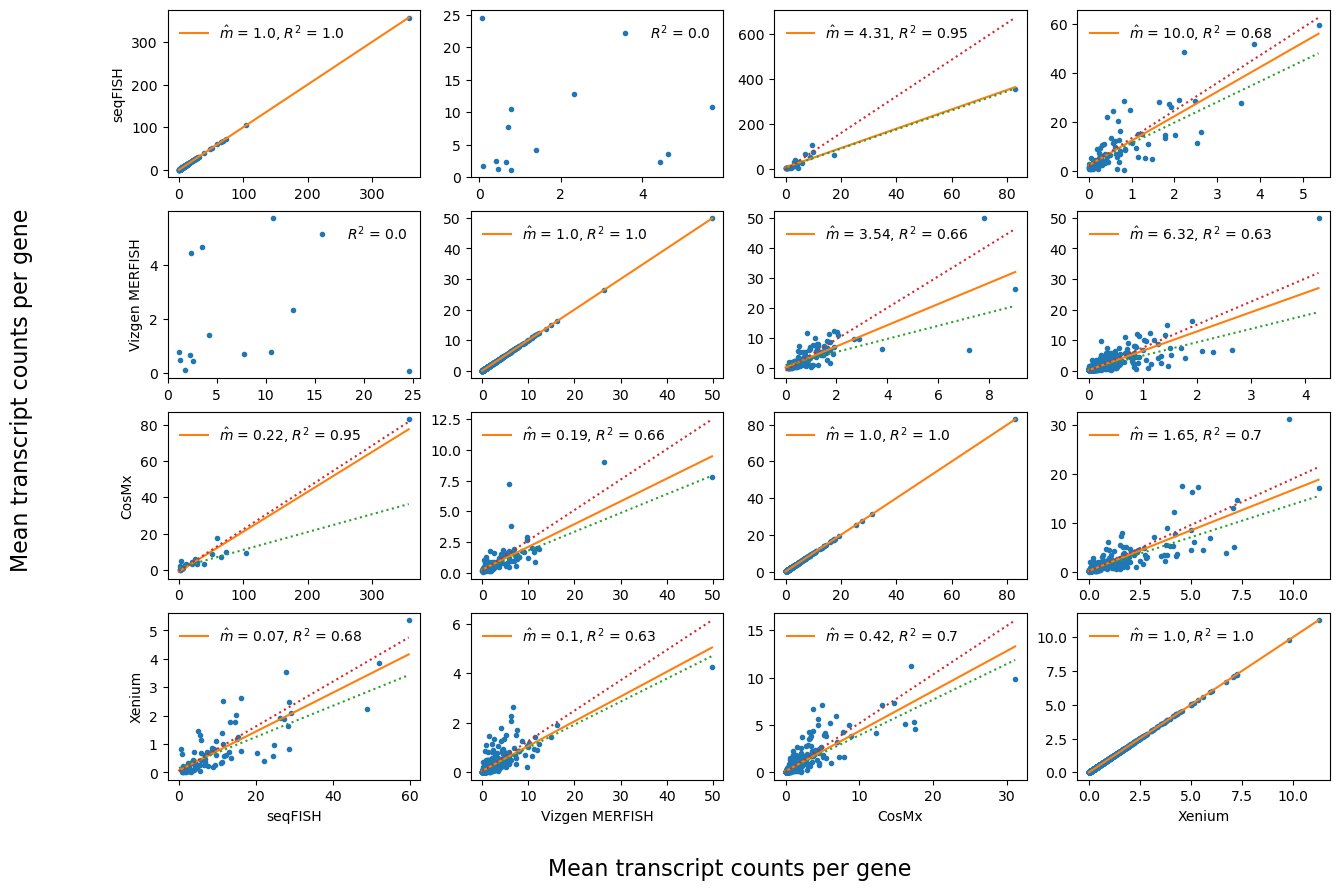

In [14]:

fig, ax = plt.subplots(4,4, figsize= [15,10])
for i, method_i in enumerate(means_by_method.columns):
    ax[i,0].set_ylabel(method_i)
    ax[3,i].set_xlabel(method_i)
    for j, method_j in enumerate(means_by_method.columns):
        #matched_genes = pd.DataFrame({method_i: means_by_method[method_i], method_j : means_by_method[method_j]}).dropna()
        if method_i == method_j:
            matched_genes = means_by_method.loc[:, method_i].dropna()
            matched_genes_alt = pd.DataFrame({method_i: means_by_method[method_i], method_j : means_by_method[method_j]}).dropna()
            fit = linregress(matched_genes, matched_genes)
            slope_label = r"$\hat m$ = {best}".format(best=np.round(fit.slope,2)) #, low=bounds['el_slope'], up=bounds['eu_slope'])
            r_sq_label = r", $R^2$ = {r_sq}".format(r_sq=np.round(fit.rvalue**2, 2)) #, low=bounds['el_r_sq'], up=bounds['eu_r_sq'])
            label_text = slope_label + r_sq_label

            ax[j,i].plot(matched_genes_alt[method_i], matched_genes_alt[method_j], '.')
            ax[j,i].plot([0, np.max(matched_genes)], [fit.intercept, fit.intercept + fit.slope *np.max(matched_genes)], label = label_text)
            ax[j,i].legend(frameon=False)
            #boot_res = bootstrap(matched_genes_alt)
            #ax[j,i].plot([0, np.max(matched_genes_alt[method_i])], [boot_res['intercept'].iloc[0], boot_res['intercept'].iloc[0] + boot_res['slope'].iloc[0] *np.max(matched_genes[method_i])], ':')#, label = r"$m_\text{l}$ = " + str(np.round(boot_res['slope'].iloc[0],2)))
            #ax[j,i].plot([0, np.max(matched_genes_alt[method_i])], [boot_res['intercept'].iloc[1], boot_res['intercept'].iloc[1] + boot_res['slope'].iloc[1] *np.max(matched_genes[method_i])], ':')#, label = r"$m_\text{u}$ = " + str(np.round(boot_res['slope'].iloc[1],2)))


        else:
            matched_genes = means_by_method.loc[:, [method_i, method_j]].dropna()
            fit = linregress(matched_genes[method_i], matched_genes[method_j])

            if fit.rvalue**2 > 0.1:
                boot_res = bootstrap(matched_genes)
                ax[j,i].plot(matched_genes[method_i], matched_genes[method_j], '.')
                slope_label = r"$\hat m$ = {best}".format(best=np.round(fit.slope,2)) #, low=bounds['el_slope'], up=bounds['eu_slope'])
                r_sq_label = r", $R^2$ = {r_sq}".format(r_sq=np.round(fit.rvalue**2, 2)) #, low=bounds['el_r_sq'], up=bounds['eu_r_sq'])
                label_text = slope_label + r_sq_label
                ax[j,i].plot([0, np.max(matched_genes[method_i])], [fit.intercept, fit.intercept + fit.slope *np.max(matched_genes[method_i])], label = label_text)
                ax[j,i].plot([0, np.max(matched_genes[method_i])], [boot_res['intercept'].iloc[0], boot_res['intercept'].iloc[0] + boot_res['slope'].iloc[0] *np.max(matched_genes[method_i])], ':')#, label = r"$m_\text{l}$ = " + str(np.round(boot_res['slope'].iloc[0],2)))
                ax[j,i].plot([0, np.max(matched_genes[method_i])], [boot_res['intercept'].iloc[1], boot_res['intercept'].iloc[1] + boot_res['slope'].iloc[1] *np.max(matched_genes[method_i])], ':')#, label = r"$m_\text{u}$ = " + str(np.round(boot_res['slope'].iloc[1],2)))
                boot_res['intercept'].iloc[0]
            else:
                ax[j,i].plot(matched_genes[method_i], matched_genes[method_j], '.', label=r"$R^2$ = " + str(np.round(fit.rvalue**2, 2)))
            ax[j,i].legend(frameon=False)

fig.supxlabel("Mean transcript counts per gene", fontsize=16)
fig.supylabel("Mean transcript counts per gene", fontsize=16)
plt.savefig("SFig4A_cortex_benchmark.pdf")

In [ ]:

fig, ax = plt.subplots(4,4, figsize= [6,4])
for i, method_i in enumerate(means_by_method.columns):
    ax[i,0].set_ylabel(method_i, fontsize=7)
    ax[3,i].set_xlabel(method_i, fontsize=7)
    for j, method_j in enumerate(means_by_method.columns):
        #matched_genes = pd.DataFrame({method_i: means_by_method[method_i], method_j : means_by_method[method_j]}).dropna()
        if method_i == method_j:
            matched_genes = means_by_method.loc[:, method_i].dropna()
            matched_genes_alt = pd.DataFrame({method_i: means_by_method[method_i], method_j : means_by_method[method_j]}).dropna()
            fit = linregress(matched_genes, matched_genes)
            slope_label = r"$\hat m$ = {best}".format(best=np.round(fit.slope,2)) #, low=bounds['el_slope'], up=bounds['eu_slope'])
            r_sq_label = r", $R^2$ = {r_sq}".format(r_sq=np.round(fit.rvalue**2, 2)) #, low=bounds['el_r_sq'], up=bounds['eu_r_sq'])
            label_text = slope_label + r_sq_label

            ax[j,i].plot(matched_genes_alt[method_i], matched_genes_alt[method_j], '.')
            ax[j,i].plot([0, np.max(matched_genes)], [fit.intercept, fit.intercept + fit.slope *np.max(matched_genes)], label = label_text)
            ax[j,i].legend(frameon=False, fontsize=7)
            #boot_res = bootstrap(matched_genes_alt)
            #ax[j,i].plot([0, np.max(matched_genes_alt[method_i])], [boot_res['intercept'].iloc[0], boot_res['intercept'].iloc[0] + boot_res['slope'].iloc[0] *np.max(matched_genes[method_i])], ':')#, label = r"$m_\text{l}$ = " + str(np.round(boot_res['slope'].iloc[0],2)))
            #ax[j,i].plot([0, np.max(matched_genes_alt[method_i])], [boot_res['intercept'].iloc[1], boot_res['intercept'].iloc[1] + boot_res['slope'].iloc[1] *np.max(matched_genes[method_i])], ':')#, label = r"$m_\text{u}$ = " + str(np.round(boot_res['slope'].iloc[1],2)))


        else:
            matched_genes = means_by_method.loc[:, [method_i, method_j]].dropna()
            fit = linregress(matched_genes[method_i], matched_genes[method_j])

            if fit.rvalue**2 > 0.1:
                boot_res = bootstrap(matched_genes)
                ax[j,i].plot(matched_genes[method_i], matched_genes[method_j], '.')
                slope_label = r"$\hat m$ = {best}".format(best=np.round(fit.slope,2)) #, low=bounds['el_slope'], up=bounds['eu_slope'])
                r_sq_label = r", $R^2$ = {r_sq}".format(r_sq=np.round(fit.rvalue**2, 2)) #, low=bounds['el_r_sq'], up=bounds['eu_r_sq'])
                label_text = slope_label + r_sq_label
                ax[j,i].plot([0, np.max(matched_genes[method_i])], [fit.intercept, fit.intercept + fit.slope *np.max(matched_genes[method_i])], label = label_text)
                ax[j,i].plot([0, np.max(matched_genes[method_i])], [boot_res['intercept'].iloc[0], boot_res['intercept'].iloc[0] + boot_res['slope'].iloc[0] *np.max(matched_genes[method_i])], ':')#, label = r"$m_\text{l}$ = " + str(np.round(boot_res['slope'].iloc[0],2)))
                ax[j,i].plot([0, np.max(matched_genes[method_i])], [boot_res['intercept'].iloc[1], boot_res['intercept'].iloc[1] + boot_res['slope'].iloc[1] *np.max(matched_genes[method_i])], ':')#, label = r"$m_\text{u}$ = " + str(np.round(boot_res['slope'].iloc[1],2)))
                boot_res['intercept'].iloc[0]
            else:
                ax[j,i].plot(matched_genes[method_i], matched_genes[method_j], '.', label=r"$R^2$ = " + str(np.round(fit.rvalue**2, 2)))
            ax[j,i].legend(frameon=False, fontsize=7)

fig.supxlabel("Mean transcript counts per gene", fontsize=7)
fig.supylabel("Mean transcript counts per gene", fontsize=7)
plt.tight_layout()
#plt.savefig("SFig4A_cortex_benchmark.pdf")